In [84]:
import pandas as pd
import numpy as np
import datetime as dt

from statsmodels.tsa.api import STLForecast
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [85]:
df_fall = pd.read_csv("data.csv")
power = np.array(df_fall["power"])

In [86]:
import numpy as np
import pandas as pd
from sktime.forecasting.statsforecast import StatsForecastMSTL

# Assuming `power` is your time series data

# Define the index for splitting the data
split_index = 71423

# Split the data into training and testing sets
train_data = power[:split_index].copy()
test_data = power[split_index:].copy()

# Define the forecasting horizon
forecast_steps = len(test_data)  # Total steps to forecast
forecast_horizon = 16  # Steps to forecast at a time

# Define the model
model = StatsForecastMSTL(season_length=[96, 96*7])  # Assuming multiple seasonalities of 96 and 7 days

# Initialize a list to store forecasted values
forecasted_values = []

# # Fit the initial model using all the training data
# fitted_model = model.fit(train_data)

# Iterate over forecast_steps in steps of forecast_horizon
for i in range(0, forecast_steps, forecast_horizon):
    # Concatenate training data and test data up to the current point in time
    train = power[split_index + i - 20 * 96 : split_index + i]
    
    # Fit the model using all available data up to the current point in time
    fitted_model = model.fit(train)
    
    # Forecast next 16 steps
    fh = np.arange(1, 17)
    y_pred = list(fitted_model.predict(fh=fh))
    
    # Append forecasted values
    forecasted_values.extend(y_pred)  # Only append the last 16 forecasts

In [87]:
forecast = forecasted_values.copy()

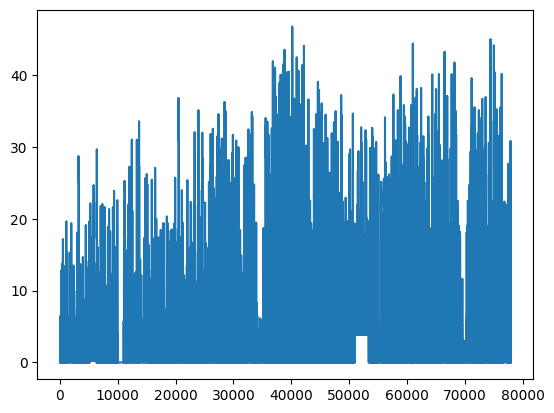

In [88]:
plt.plot(power)

In [89]:
len(power)

77952

In [90]:
len(forecasted_values)

6544

In [91]:
forecasted_values[-10:]

[array([0.16917307]),
 array([0.169163]),
 array([0.16933973]),
 array([0.16968544]),
 array([0.17018279]),
 array([0.17081539]),
 array([0.17156748]),
 array([0.17148242]),
 array([0.17150162]),
 array([0.17161047])]

In [92]:
len(test_data)

6529

In [93]:
test_data[-10:]

array([-1.36769913e-07, -1.36769913e-07, -1.36769913e-07, -1.36769913e-07,
       -1.36769913e-07, -1.36769913e-07, -1.36769913e-07, -1.36769913e-07,
       -1.36769913e-07, -1.36769913e-07])

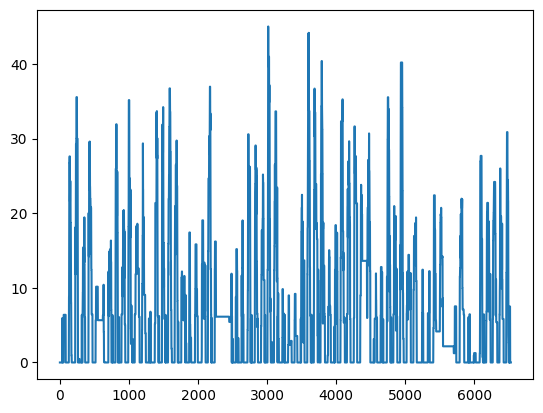

In [96]:
plt.plot(power[split_index:])

In [97]:
y_test = np.array(power[split_index:])

In [116]:
forecast = np.array(forecast).flatten()
forecast = [0 if f < 0 else f for f in forecast]

alpha = 0.2

mse = mean_squared_error(forecast, power[split_index:])

weights = alpha ** (1 + np.sign(power[split_index:], y_test))
wmse = mean_squared_error(forecast, power[split_index:], sample_weight=weights)



In [117]:
mse

84.6977641331548

In [118]:
wmse

76.32552964946653

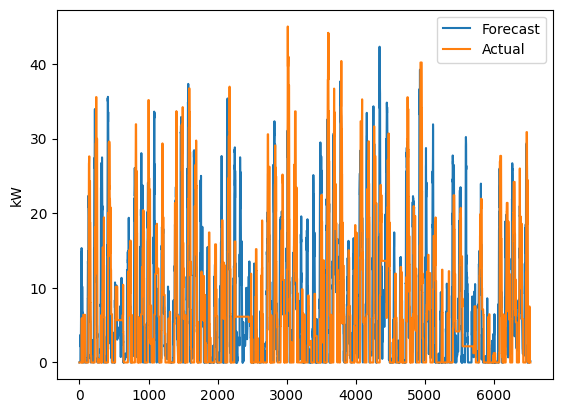

In [121]:
plt.plot(forecast, label="Forecast")
plt.plot(power[split_index:], label="Actual")
plt.legend()
plt.ylabel("kW");